In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

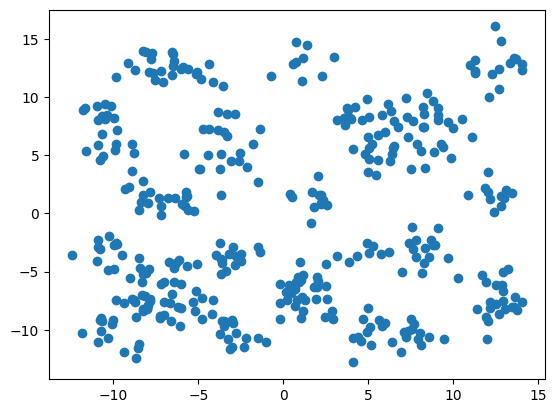

In [17]:
from sklearn.decomposition import PCA

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X_train= train_df.drop(columns=['SampleID'])
X_test= test_df.drop(columns=['SampleID'])

pca = PCA(n_components=2, svd_solver='full', random_state= seed)

Plotting= pca.fit_transform(X_train).reshape((2, -1))

plt.scatter(Plotting[0], Plotting[1])
plt.show()

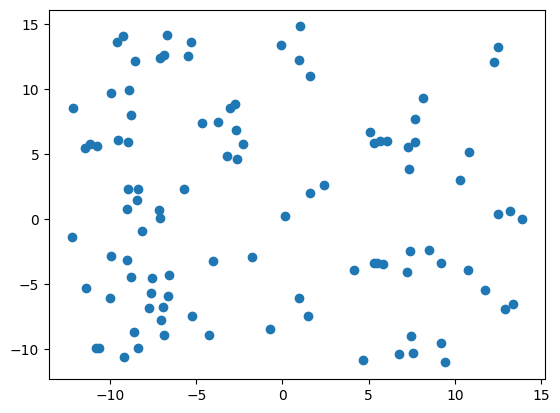

In [18]:
Plotting= pca.transform(X_test).reshape((2, -1))

plt.scatter(Plotting[0], Plotting[1])
plt.show()

In [ ]:
from sklearn.cluster import KMeans 

model= KMeans(
    4,
    n_init=100,
    max_iter=1000,
    random_state= seed
)
model.fit(X_train)

predictions= model.predict(X_test)

answer= pd.DataFrame([{
    'SampleID': id_,
    'Label': pred
} for id_, pred in zip(test_df['SampleID'], predictions)])

answer.head()

In [ ]:
answer.to_csv("submission.csv", index= False)